In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ast
from tqdm import tqdm

# ==============================================================
# Chunk 1 – Load unified dataset and extract unique cells
# ==============================================================
df = pd.read_csv("/kaggle/input/datasets/mohamedaln/merfish-moffitt-boundaries-unified/MERFISH_Moffitt_Boundaries_UNIFIED.csv")
print(f"Total rows (molecule-level): {len(df)}")

# Deduplicate to cell-level (one row per cell)
df_cells = df.drop_duplicates(subset="Cell_ID").reset_index(drop=True)
print(f"Unique cells: {len(df_cells)}")
print(f"Cell classes: {df_cells['Cell_class'].nunique()}")
print(df_cells["Cell_class"].value_counts())

# ==============================================================
# Chunk 2 – Parse boundary coordinates
# ==============================================================
import json

def parse_boundary(val):
    if isinstance(val, str):
        val = val.replace('nan', 'null')
        import json
        arr = json.loads(val)
        return np.array([x if x is not None else np.nan for x in arr])
    return np.array(val)

df_cells["Boundaries_X_parsed"] = df_cells["boundaryX"].apply(parse_boundary)
df_cells["Boundaries_Y_parsed"] = df_cells["boundaryY"].apply(parse_boundary)
print("Boundaries parsed successfully.")

Total rows (molecule-level): 1568209
Unique cells: 5543
Cell classes: 15
Cell_class
Inhibitory       2219
Excitatory       1219
Astrocyte         745
Endothelial 1     301
OD Mature 2       241
OD Immature 1     223
Ependymal         219
Endothelial 3     117
Microglia         106
Pericytes          62
OD Mature 1        49
Endothelial 2      19
OD Mature 4        10
OD Immature 2       7
OD Mature 3         6
Name: count, dtype: int64
Boundaries parsed successfully.


Plotting all cells: 100%|██████████| 5543/5543 [00:07<00:00, 705.35it/s]


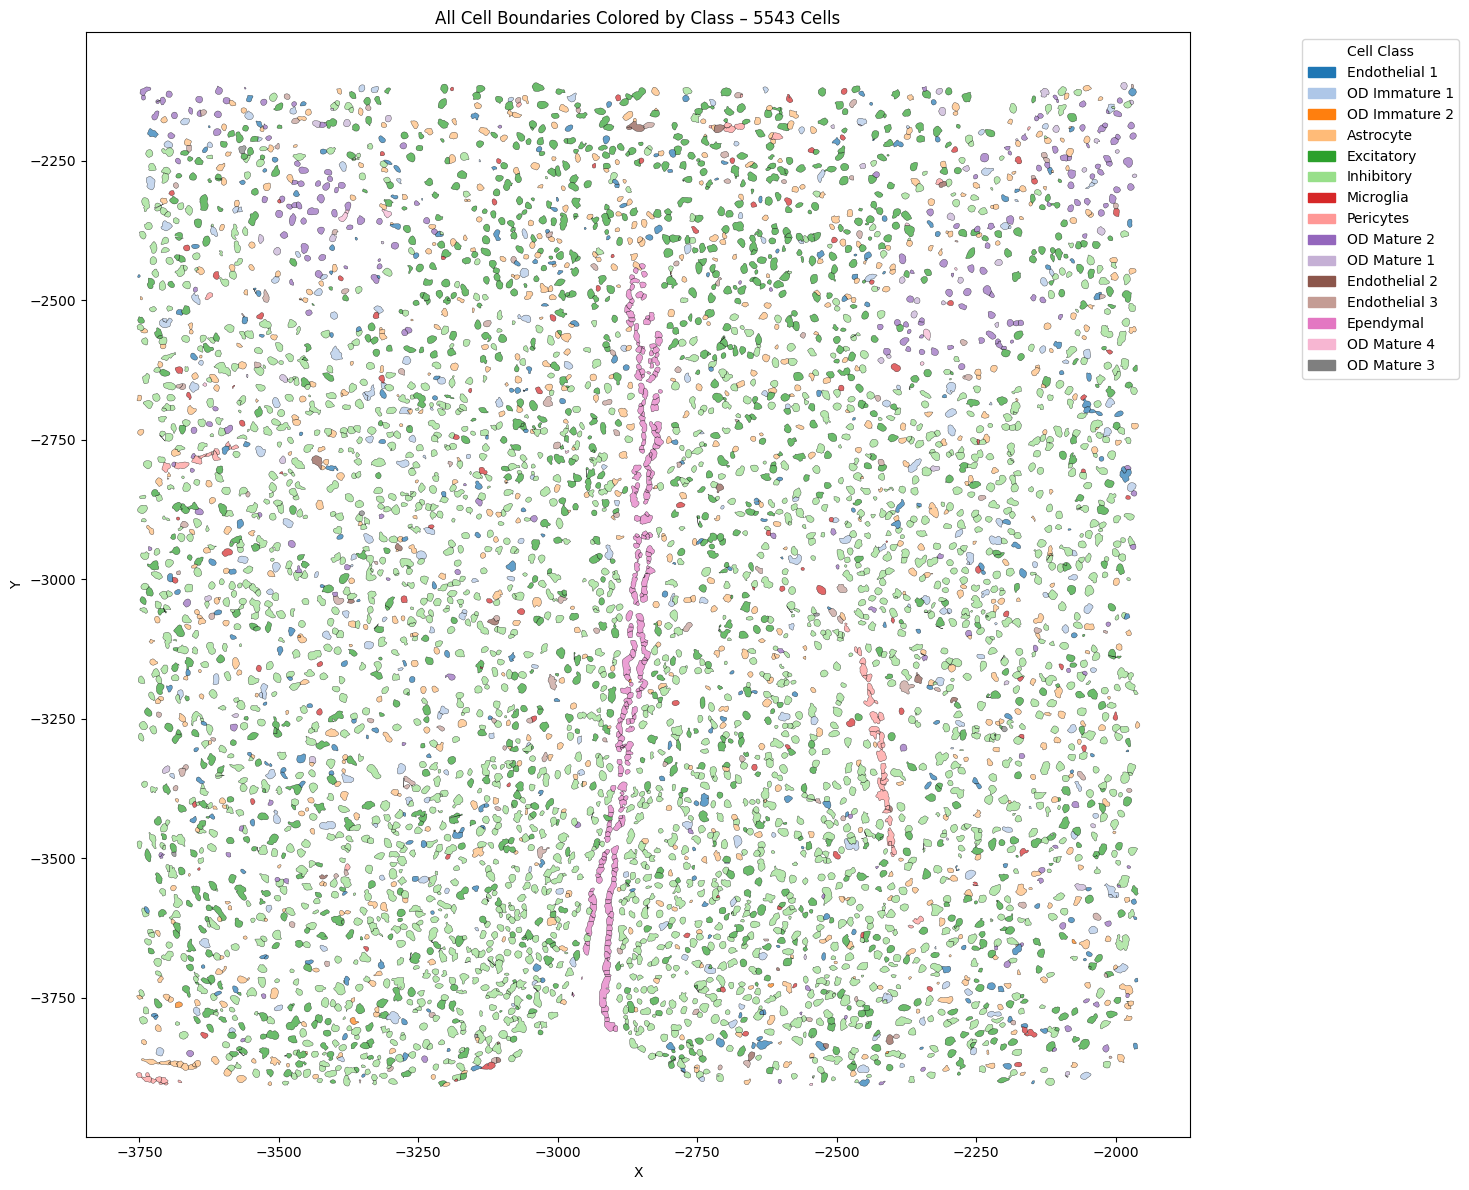

Plotting zoom 1: 100%|██████████| 502/502 [00:00<00:00, 732.85it/s]


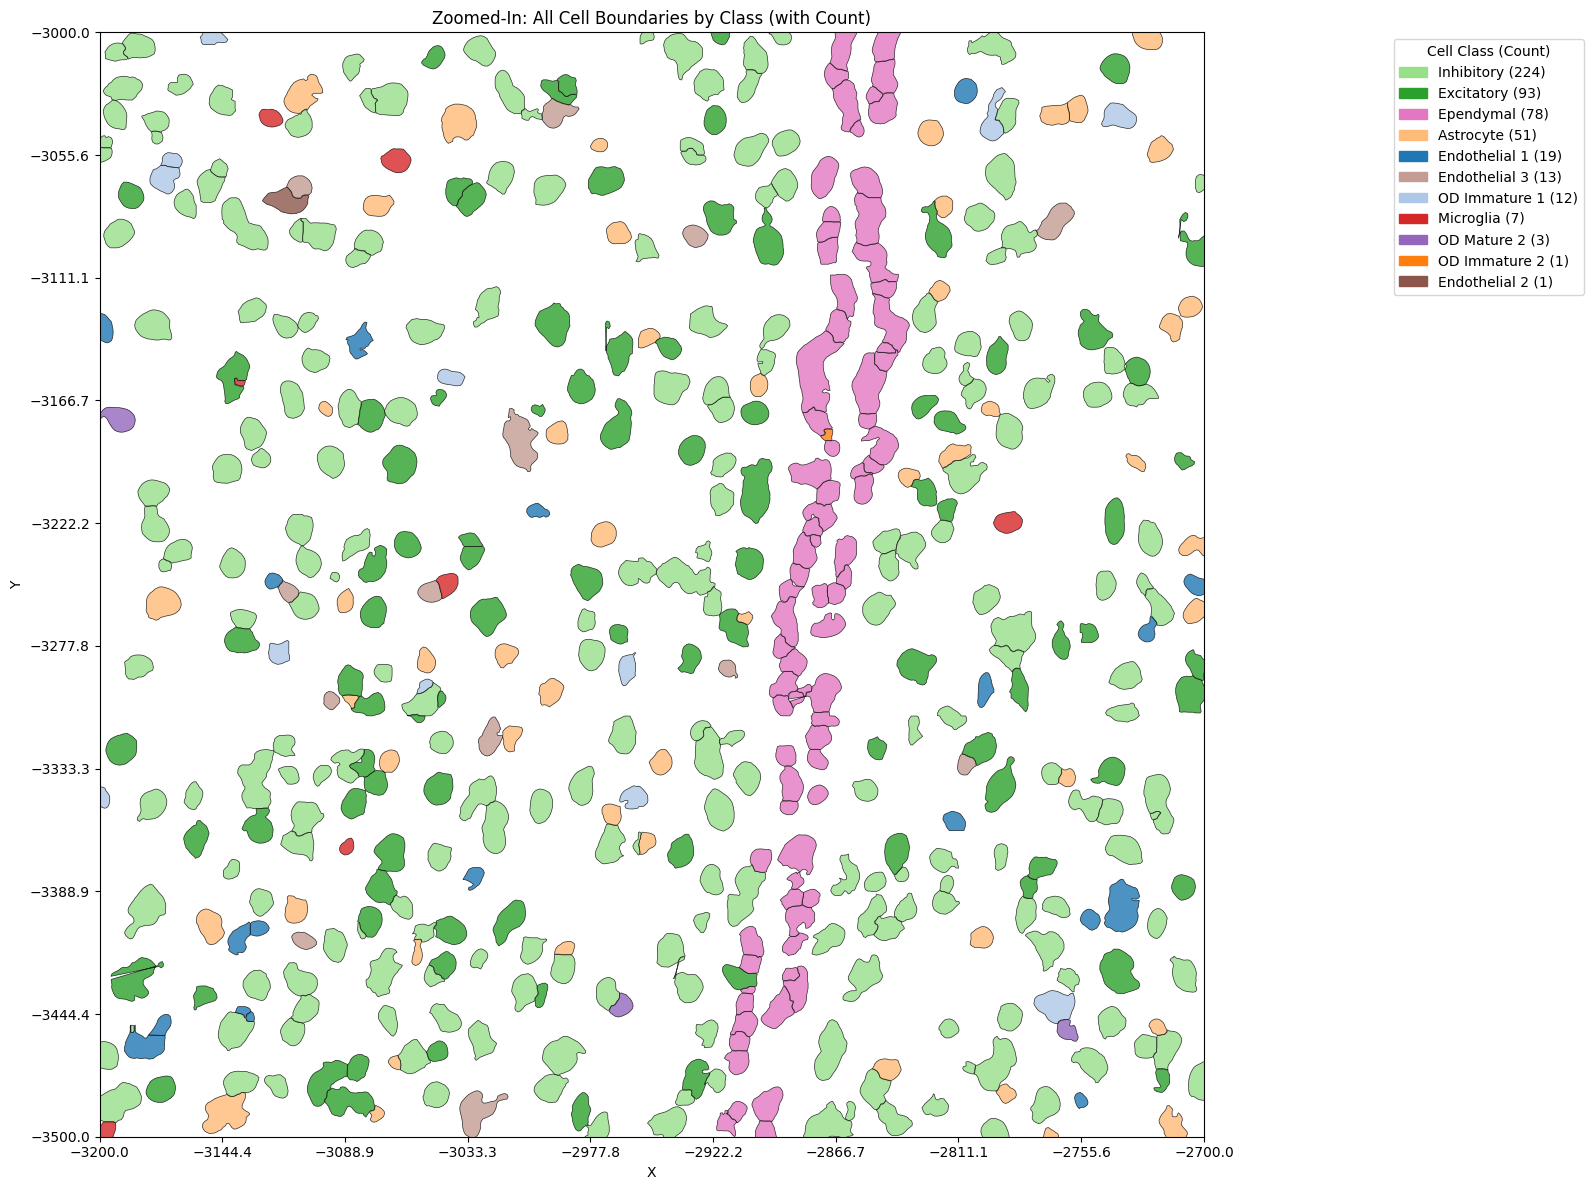

Plotting zoom 2: 100%|██████████| 409/409 [00:00<00:00, 733.33it/s]


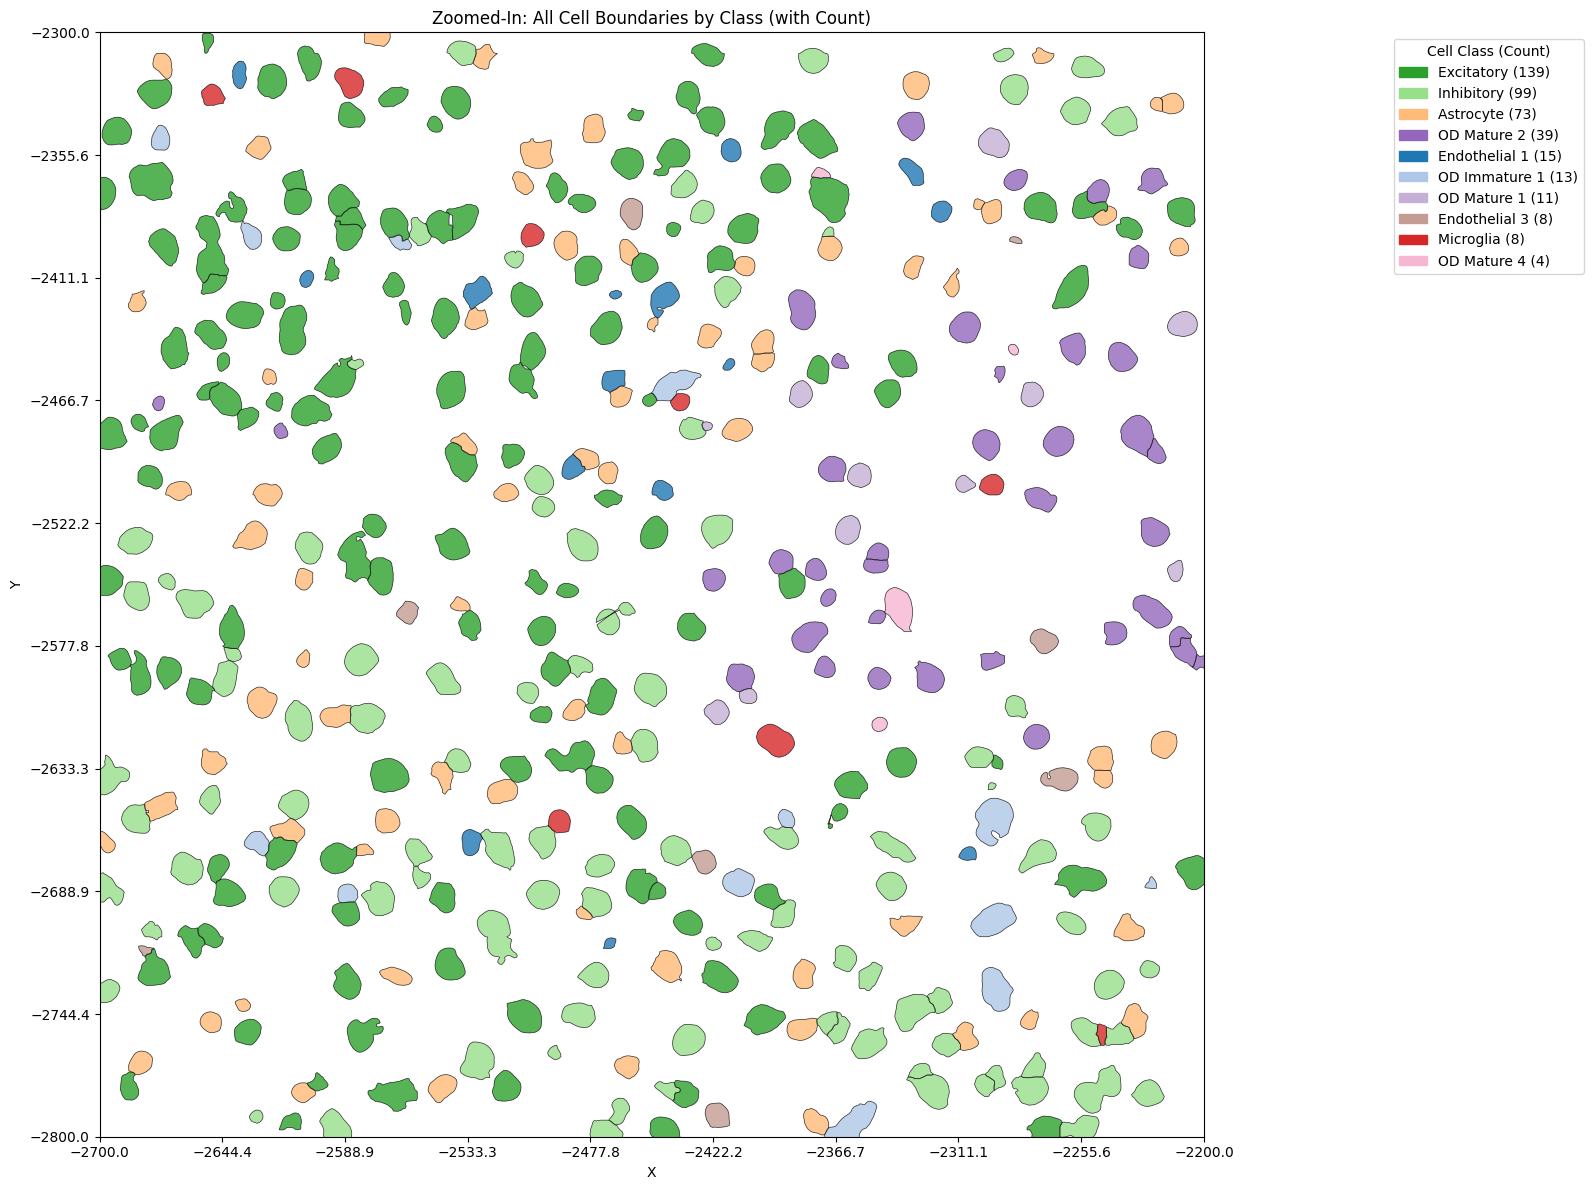

In [16]:
# ==============================================================
# Chunk 3 – Plot ALL cell boundaries colored by Cell_class
# ==============================================================
unique_classes = df_cells["Cell_class"].unique()
cmap = plt.colormaps['tab20']
color_dict = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_classes)}

plt.figure(figsize=(14, 12))

for _, row in tqdm(df_cells.iterrows(), total=len(df_cells), desc="Plotting all cells", colour="green"):
    cls = row["Cell_class"]
    bx = row["Boundaries_X_parsed"]
    by = row["Boundaries_Y_parsed"]
    plt.fill(bx, by, color=color_dict[cls], linewidth=0.3, edgecolor='black', alpha=0.7)

# Legend
handles = [mpatches.Patch(color=color_dict[cls], label=cls) for cls in unique_classes]
plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.25, 1.0), title="Cell Class")

plt.title(f"All Cell Boundaries Colored by Class – {len(df_cells)} Cells")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

# ==============================================================
# Chunk 4 – Zoomed-In view with per-class count in legend
# ==============================================================
x_start, x_end = -3200, -2700
y_start, y_end = -3500, -3000

zoom_df = df_cells[
    (df_cells["Cell_Centroid_X"] >= x_start) & (df_cells["Cell_Centroid_X"] <= x_end) &
    (df_cells["Cell_Centroid_Y"] >= y_start) & (df_cells["Cell_Centroid_Y"] <= y_end)
]

zoom_class_counts = zoom_df["Cell_class"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 12))

for _, row in tqdm(zoom_df.iterrows(), total=len(zoom_df), desc="Plotting zoom 1", colour="green"):
    cls = row["Cell_class"]
    bx = row["Boundaries_X_parsed"]
    by = row["Boundaries_Y_parsed"]
    plt.fill(bx, by, color=color_dict[cls], linewidth=0.5, edgecolor='black', alpha=0.8)

# Legend with counts
handles = []
for cls in zoom_class_counts.index:
    label = f"{cls} ({zoom_class_counts[cls]})"
    handles.append(mpatches.Patch(color=color_dict[cls], label=label))

plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.35, 1.0), title="Cell Class (Count)")
plt.title("Zoomed-In: All Cell Boundaries by Class (with Count)")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(x_start, x_end)
plt.ylim(y_start, y_end)
plt.xticks(np.linspace(x_start, x_end, 10))
plt.yticks(np.linspace(y_start, y_end, 10))
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

# ==============================================================
# Chunk 5 – Second zoomed view (different region)
# ==============================================================
x_start, x_end = -2700, -2200
y_start, y_end = -2800, -2300

zoom_df2 = df_cells[
    (df_cells["Cell_Centroid_X"] >= x_start) & (df_cells["Cell_Centroid_X"] <= x_end) &
    (df_cells["Cell_Centroid_Y"] >= y_start) & (df_cells["Cell_Centroid_Y"] <= y_end)
]

zoom_class_counts2 = zoom_df2["Cell_class"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 12))

for _, row in tqdm(zoom_df2.iterrows(), total=len(zoom_df2), desc="Plotting zoom 2", colour="green"):
    cls = row["Cell_class"]
    bx = row["Boundaries_X_parsed"]
    by = row["Boundaries_Y_parsed"]
    plt.fill(bx, by, color=color_dict[cls], linewidth=0.5, edgecolor='black', alpha=0.8)

# Legend with counts
handles = []
for cls in zoom_class_counts2.index:
    label = f"{cls} ({zoom_class_counts2[cls]})"
    handles.append(mpatches.Patch(color=color_dict[cls], label=label))

plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.35, 1.0), title="Cell Class (Count)")
plt.title("Zoomed-In: All Cell Boundaries by Class (with Count)")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(x_start, x_end)
plt.ylim(y_start, y_end)
plt.xticks(np.linspace(x_start, x_end, 10))
plt.yticks(np.linspace(y_start, y_end, 10))
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()